1. Installing Necessary libraries

In [1]:
import os
import json
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import shap

print("Pandas:", pd.__version__)
print("Sklearn ready")
print("SHAP:", shap.__version__)


Pandas: 3.0.1
Sklearn ready
SHAP: 0.50.0


2.Configuration

In [2]:
TRAIN_PATH = r"train\train.csv"

RANDOM_STATE = 42
CHUNKSIZE = 250_000

# Sampling limits so the experiment runs on a normal laptop
BASELINE_SAMPLE_ROWS = 400_000
ZERO_DAY_TRAIN_ROWS = 400_000
ZERO_DAY_TEST_ROWS = 200_000

# Zero-day attacks are excluded from training and used only for zero-day testing
ZERO_DAY_ATTACKS = {
    "SqlInjection",
    "XSS",
    "CommandInjection",
    "BrowserHijacking",
    "Uploading_Attack",
    "Backdoor_Malware",
    "DictionaryBruteForce",
}

def make_binary_y(label: str) -> int:
    """BenignTraffic = 0, all attack classes = 1."""
    return 0 if label == "BenignTraffic" else 1

def prepare_xy(df: pd.DataFrame):
    """Separate features and target, ensure numeric features, handle missing values."""
    y = df["y"].astype(int)
    X = df.drop(columns=["label", "y"], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    return X, y


3.Dataset Inspection

In [3]:
sample = pd.read_csv(TRAIN_PATH, nrows=5)
print("Shape of small sample:", sample.shape)
print("Columns:", list(sample.columns))
sample.head()


Shape of small sample: (5, 47)
Columns: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


4. Dataset statistics using Chunk loading

In [4]:
# This counts total rows and label distribution without loading the full dataset at once.

total_rows = 0
label_counts = Counter()
missing_counts = None

for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    total_rows += len(chunk)
    label_counts.update(chunk["label"])

    chunk_missing = chunk.isnull().sum()
    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts += chunk_missing

print("Total rows:", total_rows)
print("Number of unique labels:", len(label_counts))
print("\nTop 20 labels:")
for label, count in label_counts.most_common(20):
    print(f"{label}: {count}")

print("\nColumns with missing values:")
print(missing_counts[missing_counts > 0])


Total rows: 5491971
Number of unique labels: 34

Top 20 labels:
DDoS-ICMP_Flood: 848088
DDoS-UDP_Flood: 637558
DDoS-TCP_Flood: 528499
DDoS-PSHACK_Flood: 481254
DDoS-SYN_Flood: 478653
DDoS-RSTFINFlood: 475441
DDoS-SynonymousIP_Flood: 422083
DoS-UDP_Flood: 390422
DoS-TCP_Flood: 314174
DoS-SYN_Flood: 237573
BenignTraffic: 129538
Mirai-greeth_flood: 116133
Mirai-udpplain: 104814
Mirai-greip_flood: 88821
DDoS-ICMP_Fragmentation: 53046
MITM-ArpSpoofing: 36316
DDoS-UDP_Fragmentation: 34169
DDoS-ACK_Fragmentation: 33581
DNS_Spoofing: 21214
Recon-HostDiscovery: 15737

Columns with missing values:
Series([], dtype: int64)


In [5]:
# Convert label counts to dataframe for easier reporting
label_df = pd.DataFrame(label_counts.items(), columns=["label", "count"]).sort_values("count", ascending=False)
label_df.head(20)


,label,count
5,DDoS-ICMP_Flood,848088
7,DDoS-UDP_Flood,637558
6,DDoS-TCP_Flood,528499
2,DDoS-PSHACK_Flood,481254
1,DDoS-SYN_Flood,478653
14,DDoS-RSTFINFlood,475441
12,DDoS-SynonymousIP_Flood,422083
13,DoS-UDP_Flood,390422
11,DoS-TCP_Flood,314174
4,DoS-SYN_Flood,237573


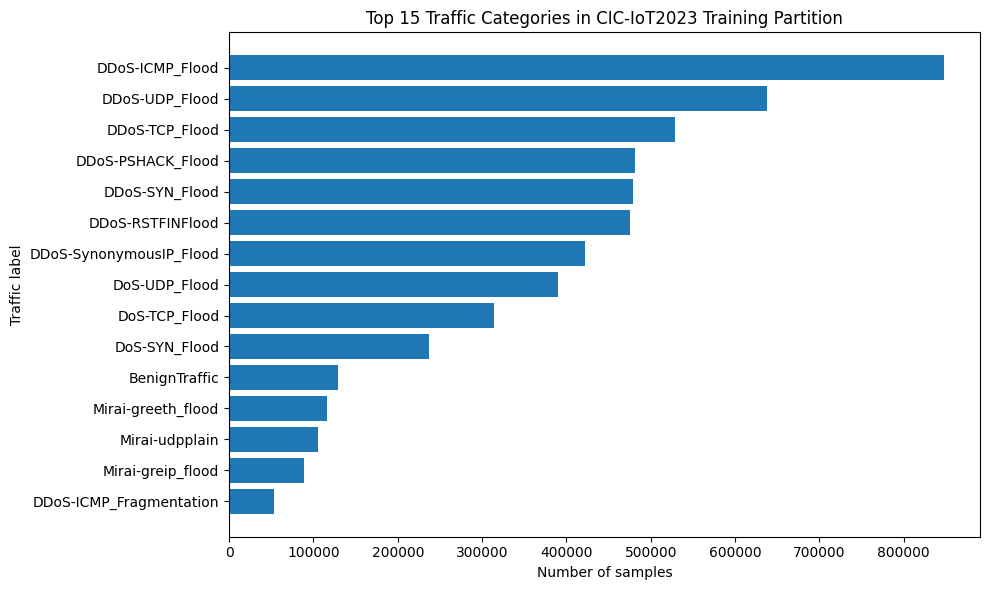

In [6]:
# Plot top 15 labels
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(label_df.head(top_n)["label"][::-1], label_df.head(top_n)["count"][::-1])
plt.xlabel("Number of samples")
plt.ylabel("Traffic label")
plt.title("Top 15 Traffic Categories in CIC-IoT2023 Training Partition")
plt.tight_layout()
plt.show()


5. Baseline experiment, Normal Random Split

In [7]:
# This experiment samples from the dataset and uses a standard stratified train/test split.  
# It represents performance when attack types are not intentionally excluded from training.

def load_baseline_sample():
    parts = []
    count = 0

    # Use total_rows if already computed; otherwise use known value from previous run
    sampling_frac = BASELINE_SAMPLE_ROWS / total_rows

    for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
        chunk["y"] = chunk["label"].apply(make_binary_y)

        # Sample from each chunk to avoid loading full dataset
        sampled = chunk.sample(frac=sampling_frac, random_state=RANDOM_STATE)
        parts.append(sampled)
        count += len(sampled)

        if count >= BASELINE_SAMPLE_ROWS:
            break

    df = pd.concat(parts, ignore_index=True)

    # Exact cap if slightly above
    if len(df) > BASELINE_SAMPLE_ROWS:
        df = df.sample(n=BASELINE_SAMPLE_ROWS, random_state=RANDOM_STATE)

    return df

baseline_df = load_baseline_sample()
print("Baseline sample shape:", baseline_df.shape)
print(baseline_df["y"].value_counts())


Baseline sample shape: (399992, 48)
y
1    390642
0      9350
Name: count, dtype: int64


In [8]:
X_base, y_base = prepare_xy(baseline_df)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    stratify=y_base,
    random_state=RANDOM_STATE
)

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_baseline.fit(X_train_b, y_train_b)
pred_b = rf_baseline.predict(X_test_b)

print("Baseline Confusion Matrix:")
print(confusion_matrix(y_test_b, pred_b))

print("\nBaseline Classification Report:")
print(classification_report(y_test_b, pred_b, digits=4))


Baseline Confusion Matrix:
[[ 1744   126]
 [  112 78017]]

Baseline Classification Report:
              precision    recall  f1-score   support

           0     0.9397    0.9326    0.9361      1870
           1     0.9984    0.9986    0.9985     78129

    accuracy                         0.9970     79999
   macro avg     0.9690    0.9656    0.9673     79999
weighted avg     0.9970    0.9970    0.9970     79999



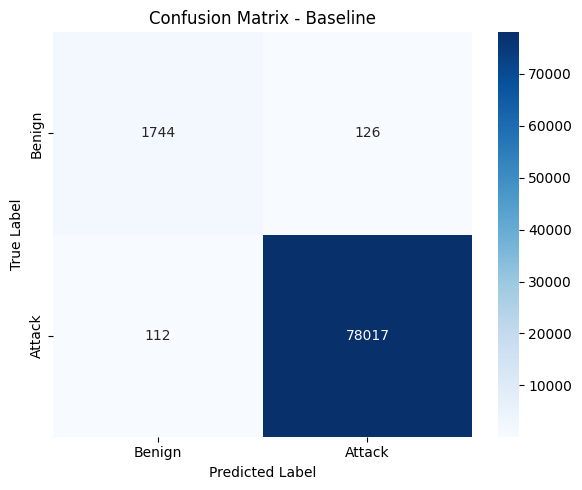

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = [[1744, 126],
      [112, 78017]]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline')
plt.tight_layout()

plt.savefig('cm_baseline.png', dpi=300)
plt.show()

6.Zero-Day Experiment: Attack-Disjoint Split

In [9]:
# The zero-day attack categories are excluded from training.  
# The test set contains these unseen attack categories plus benign traffic.

def load_zero_day_split():
    train_parts = []
    test_parts = []
    train_count = 0
    test_count = 0

    for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
        chunk["y"] = chunk["label"].apply(make_binary_y)

        is_zero_day = chunk["label"].isin(ZERO_DAY_ATTACKS)
        is_benign = chunk["label"].eq("BenignTraffic")

        # Train: seen attacks + benign
        train_chunk = chunk[~is_zero_day]

        # Test: zero-day attacks + benign
        test_chunk = chunk[is_zero_day | is_benign]

        if train_count < ZERO_DAY_TRAIN_ROWS:
            remaining = ZERO_DAY_TRAIN_ROWS - train_count
            add = train_chunk
            if len(add) > remaining:
                add = add.sample(n=remaining, random_state=RANDOM_STATE)
            train_parts.append(add)
            train_count += len(add)

        if test_count < ZERO_DAY_TEST_ROWS:
            remaining = ZERO_DAY_TEST_ROWS - test_count
            add = test_chunk
            if len(add) > remaining:
                add = add.sample(n=remaining, random_state=RANDOM_STATE)
            test_parts.append(add)
            test_count += len(add)

        if train_count >= ZERO_DAY_TRAIN_ROWS and test_count >= ZERO_DAY_TEST_ROWS:
            break

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    return train_df, test_df

train_df, test_df = load_zero_day_split()

print("Zero-day training shape:", train_df.shape)
print("Zero-day test shape:", test_df.shape)

print("\nTraining labels:")
print(train_df["y"].value_counts())

print("\nTest labels:")
print(test_df["y"].value_counts())

print("\nZero-day labels in test:")
print(test_df[test_df["label"].isin(ZERO_DAY_ATTACKS)]["label"].value_counts())


Zero-day training shape: (400000, 48)
Zero-day test shape: (133900, 48)

Training labels:
y
1    390694
0      9306
Name: count, dtype: int64

Test labels:
y
0    129538
1      4362
Name: count, dtype: int64

Zero-day labels in test:
label
DictionaryBruteForce    1541
BrowserHijacking         665
CommandInjection         620
SqlInjection             590
XSS                      414
Backdoor_Malware         392
Uploading_Attack         140
Name: count, dtype: int64


In [18]:
X_train_z, y_train_z = prepare_xy(train_df)
X_test_z, y_test_z = prepare_xy(test_df)

rf_zero_day = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_zero_day.fit(X_train_z, y_train_z)

import joblib

# Save the trained zero-day model
joblib.dump(rf_zero_day, "rf_model.pkl")

# Save feature column order
joblib.dump(X_train_z.columns, "feature_columns.pkl")

print("Zero-day model saved successfully!")

pred_z = rf_zero_day.predict(X_test_z)
pred_z = rf_zero_day.predict(X_test_z)

print("Zero-Day Confusion Matrix:")
print(confusion_matrix(y_test_z, pred_z))

print("\nZero-Day Classification Report:")
print(classification_report(y_test_z, pred_z, digits=4))


Zero-day model saved successfully!
Zero-Day Confusion Matrix:
[[123084   6454]
 [   434   3928]]

Zero-Day Classification Report:
              precision    recall  f1-score   support

           0     0.9965    0.9502    0.9728    129538
           1     0.3783    0.9005    0.5328      4362

    accuracy                         0.9486    133900
   macro avg     0.6874    0.9253    0.7528    133900
weighted avg     0.9763    0.9486    0.9584    133900



7.Result table

In [11]:
def metrics_dict(name, y_true, y_pred):
    return {
        "Experiment": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Attack Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Attack Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Attack F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

results = pd.DataFrame([
    metrics_dict("Baseline normal split", y_test_b, pred_b),
    metrics_dict("Zero-day attack-disjoint", y_test_z, pred_z),
])

results


,Experiment,Accuracy,Attack Precision,Attack Recall,Attack F1
0,Baseline normal split,0.997025,0.998388,0.998566,0.998477
1,Zero-day attack-disjoint,0.948559,0.378347,0.900504,0.532827


In [12]:
results.to_csv("results_summary.csv", index=False)
print("Saved results_summary.csv")


Saved results_summary.csv


8.SHAP Explainability

In [13]:
# SHAP is computed on a small subset because explaining thousands or millions of samples is slow. 

# Use a small sample for SHAP
X_shap = X_test_z.sample(n=min(1000, len(X_test_z)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(rf_zero_day)
raw_shap_values = explainer.shap_values(X_shap)

# Convert SHAP output to a 2D matrix for attack class explanation
if isinstance(raw_shap_values, list):
    # Older SHAP versions: list[class0, class1]
    shap_values_attack = raw_shap_values[1]
else:
    raw_shap_values = np.array(raw_shap_values)
    if raw_shap_values.ndim == 3:
        # Newer SHAP versions may return (samples, features, classes)
        shap_values_attack = raw_shap_values[:, :, 1]
    elif raw_shap_values.ndim == 2:
        # Already samples x features
        shap_values_attack = raw_shap_values
    else:
        raise ValueError(f"Unexpected SHAP shape: {raw_shap_values.shape}")

print("X_shap shape:", X_shap.shape)
print("SHAP values shape:", shap_values_attack.shape)


X_shap shape: (1000, 46)
SHAP values shape: (1000, 46)


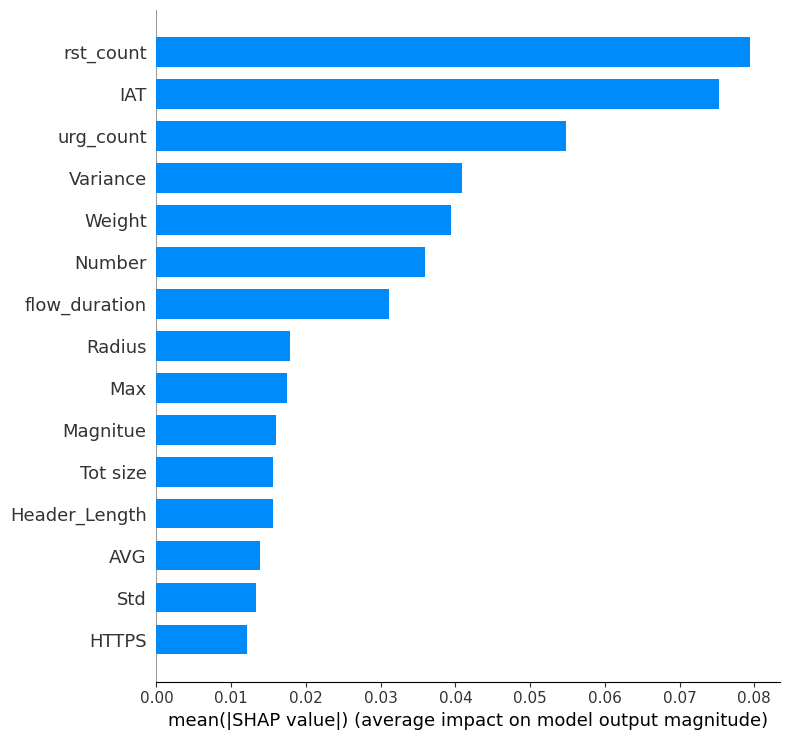

In [14]:
# SHAP bar plot: global feature importance
shap.summary_plot(
    shap_values_attack,
    X_shap,
    plot_type="bar",
    max_display=15
)


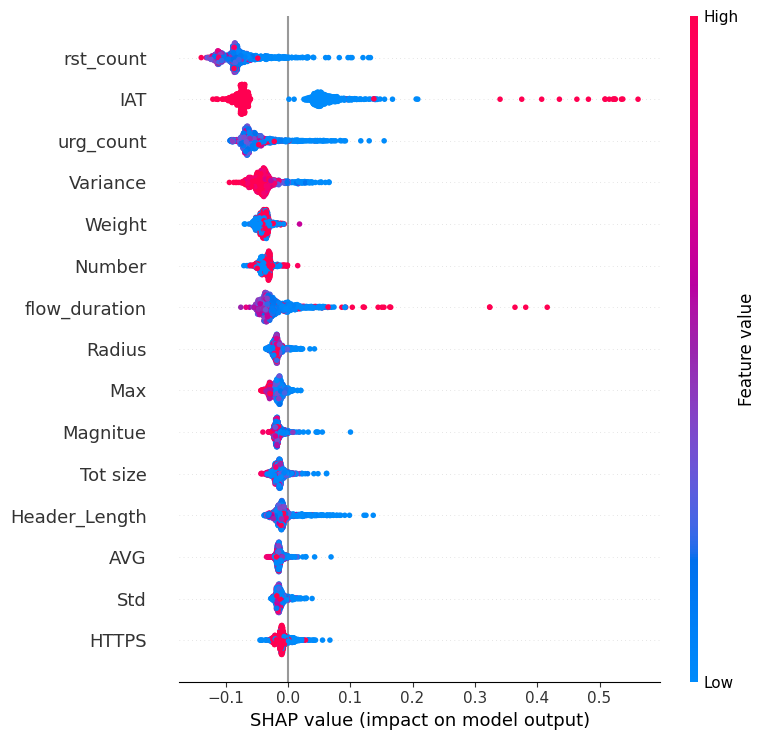

In [15]:
# SHAP beeswarm plot: direction and impact of features
shap.summary_plot(
    shap_values_attack,
    X_shap,
    max_display=15
)


In [16]:
# Print top 10 SHAP features as a table
mean_abs_shap = np.abs(shap_values_attack).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]

shap_importance = pd.DataFrame({
    "feature": X_shap.columns[top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx]
})

shap_importance


,feature,mean_abs_shap
0,rst_count,0.079466
1,IAT,0.075317
2,urg_count,0.054822
3,Variance,0.040907
4,Weight,0.039446
5,Number,0.035896
6,flow_duration,0.031087
7,Radius,0.017819
8,Max,0.017507
9,Magnitue,0.015990


In [17]:
shap_importance.to_csv("shap_feature_importance.csv", index=False)
print("Saved shap_feature_importance.csv")


Saved shap_feature_importance.csv
